In [1]:
import numpy as np
import tifffile as tiff
import h5py
import matplotlib.patches as mplpatches
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.interpolate import make_interp_spline, make_lsq_spline
from tqdm.notebook import tqdm
from scipy.optimize import leastsq
import cv2
# imgs = tiff.imread('Tissue_Chromatin_Alexa647.tif')
# imgshr = np.load('CFCNN_first-100.npy')[:,:,:,0]

In [2]:
#todo - check ThunderSTORM for drift
drift_thst = np.genfromtxt('thst_drft_40bins_50frmeach.csv',delimiter=',',skip_header=1)

In [3]:
# mydrift = np.load('cnn_detected_drift.npy')
mydrift = np.load('cnn_detected_drift2.npy')
print(mydrift.shape)



(40, 3)


In [4]:

x0, y0 = 0, 0
smoothing = 0.01
mdx = (mydrift[:,0]-x0)/4
mdy = (mydrift[:,1]-y0)/4
xarr = np.arange(40)[1:]*50
frm_bins = np.arange(41)*50
frm_centers = (frm_bins[1:] + frm_bins[:-1])*0.5

resampledx = np.interp(frm_centers[:], drift_thst[:,0], drift_thst[:,1])
resampledy = np.interp(frm_centers[:], drift_thst[:,2], drift_thst[:,3])
offset_x = np.mean(mdx - resampledx)
offset_y = np.mean(mdy - resampledy)
mdxoc = mdx-offset_x
mdyoc = mdy-offset_y
print(offset_x, offset_y)

# offset_x = 0.25/4
# offset_y = 0.25/4
#https://www.linkedin.com/pulse/splines-python-feature-selection-data-smoothing-robert-prior
def knot_points(nKnots, x, degree):
    knots = np.linspace(x[0], x[-1], nKnots) #create the knot locations
    lo = min(x[0], knots[0]) #we have to add these min and values to conform by adding preceding and proceeding values
    hi = max(x[-1], knots[-1])
    augmented_knots = np.append(np.append([lo]*degree, knots), [hi]*degree)
    return augmented_knots

iframes = np.arange(2000)
knots = knot_points(5, iframes, 3)
smoothened_x = make_lsq_spline(frm_centers, mdx, t=knots)(iframes)
smoothened_y = make_lsq_spline(frm_centers, mdy, t=knots)(iframes)
# smoothened_y = make_lsq_spline(frm_centers, mdy, knots)(iframes)

-0.05623754378726736 -0.02423492793470578


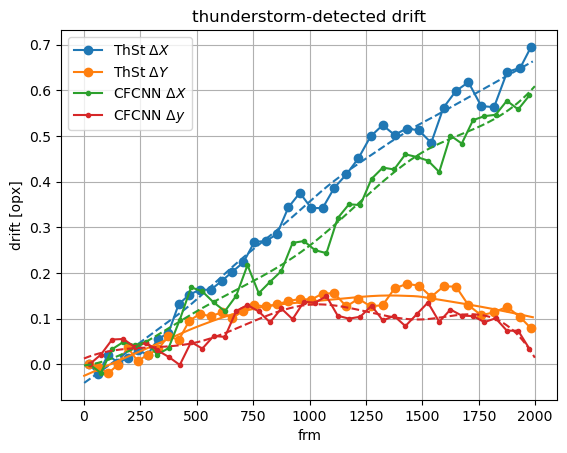

In [5]:
x0, y0 = mydrift[0,0:2]
plt.title('thunderstorm-detected drift')
plt.plot(drift_thst[:,0], drift_thst[:,1], "C0o-", label='ThSt $\\Delta X$')
plt.plot(drift_thst[:,2], drift_thst[:,3], "C1o-", label='ThSt $\\Delta Y$')
plt.plot(drift_thst[:,4], drift_thst[:,5], "C0--")
plt.plot(drift_thst[:,6], drift_thst[:,7], "C1-")
plt.plot(frm_centers[:],mdx, "C2.-", label='CFCNN $\\Delta X$')
plt.plot(frm_centers[:],mdy, "C3.-", label='CFCNN $\\Delta y$')
plt.plot(iframes[:],smoothened_x, "C2--")
plt.plot(iframes[:],smoothened_y, "C3--")
plt.xlabel('frm')
plt.ylabel('drift [opx]')
plt.grid()
plt.legend()
plt.show()

In [6]:
cnn = np.load('temp_cfcnn_all.npy', mmap_mode='r')[:,:,:]
cnn.shape


(2000, 2048, 2048)

In [72]:
#process all images without drift correction
BATCH = 10
imgr = np.zeros((cnn[0].shape))
n = cnn.shape[0]
nbatch = n//BATCH
for i in tqdm(range(nbatch)):
    chunk = cnn[i*BATCH : i*BATCH + BATCH]
    # chunkproc = np.max(chunk, axis=0)
    # sel = (chunkproc > imgr)
    # imgr[sel] = chunkproc[sel]
    chunkproc = np.sum(chunk, axis=0)
    imgr += chunkproc
imgr0 = np.copy(imgr)


  0%|          | 0/200 [00:00<?, ?it/s]

In [136]:
#process without drift correction
blur = 1
imgrb = 2
blurred0 = ndi.gaussian_filter(imgr0, blur)
blurred0 /= np.max(blurred0)
plt.imshow(blurred0**0.5)
# sumtrace = np.sum(cnn, axis=0)

In [74]:
def corect_drift(img, dx, dy):
    h, w = img.shape
    m = np.array([[1,0,-dx*4],[0,1,-dy*4]],dtype=np.float32)
    return cv2.warpAffine(img, m, (h,w))

#process all images without drift correction
BATCH = 10
imgr = np.zeros((cnn[0].shape))
n = cnn.shape[0]
nbatch = n//BATCH
for i in tqdm(range(nbatch)):
    chunk = cnn[i*BATCH : i*BATCH + BATCH]
    dxs = smoothened_x[i*BATCH : (i+1)*BATCH]
    dys = smoothened_y[i*BATCH : (i+1)*BATCH]
    chunkcorr = np.array([corect_drift(_img, dx, dy) for _img, dx, dy in zip(chunk, dxs, dys)])
    #max trace
    # chunkproc = np.max(chunkcorr, axis=0)
    # sel = (chunkproc > imgr)
    # imgr[sel] = chunkproc[sel]
    #sum
    imgr += np.sum(chunkcorr, axis=0)
imgr1 = np.copy(imgr)

  0%|          | 0/200 [00:00<?, ?it/s]

In [135]:
#process without drift correction
blur = 1
imgrb = 2
blurred1 = ndi.gaussian_filter(imgr1, blur)
blurred1 /= np.max(blurred0)
plt.imshow(blurred1**0.5)
# sumtrace = np.sum(cnn, axis=

In [90]:
np.save('cfcnn_all_sumdcorr.npy', imgr1)
np.save('cfcnn_all_sum_nocorr.npy', imgr0)

In [128]:
subsel = cnn[:,790:832,990:1032]
import tifffile
wrt = tifffile.TiffWriter('emitter.tiff', imagej=True)


# q1 = np.quantile((imgr0[s]/np.max(imgr0[s]))**gamma, 0.01)
# q2 = np.quantile((imgr0[s]/np.max(imgr0[s]))**gamma, 0.99)
imgs = 255*(subsel/(np.max(subsel)-np.min(subsel)))**0.8
wrt.write(imgs.astype(np.uint8))

In [129]:

plt.matshow(imgs[10])

In [130]:
plt.plot(np.max(imgs, axis=(1,2)))

In [104]:
plt.imshow(np.sum(subsel,axis=0))

In [138]:
%matplotlib qt
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
s = np.s_[:, :]
gamma = 0.8
q1 = np.quantile(blurred0**gamma, 0.001)
q2 = np.quantile(blurred0**gamma, 0.999)
q3 = np.quantile(blurred1**gamma, 0.001)
q4 = np.quantile(blurred1**gamma, 0.999)

ax[0].matshow(blurred0**gamma, vmin=q1, vmax=q2)
ax[1].matshow(blurred1**gamma, vmin=q3, vmax=q4)
# ax[0].set_ylim(470,520)
# ax[0].set_xlim(1210,1260)
plt.show()

In [141]:
%matplotlib qt
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
s = np.s_[:, :]
gamma = 0.9
q1 = np.quantile((imgr0[s]/np.max(imgr0[s]))**gamma, 0.001)
q2 = np.quantile((imgr0[s]/np.max(imgr0[s]))**gamma, 0.999)

ax[0].matshow(((imgr0[s]/np.max(imgr0[s]))**gamma), vmin=q1, vmax=q2)
ax[1].matshow(((imgr1[s]/np.max(imgr1[s]))**gamma), vmin=q1, vmax=q2)
# ax[0].set_ylim(470,520)
# ax[0].set_xlim(1210,1260)
plt.show()